In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")

print("Path to dataset files:", path)

100%|██████████| 16.1M/16.1M [00:00<00:00, 145MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shivamb/real-or-fake-fake-jobposting-prediction/versions/1


In [3]:
import pandas as pd
import os

# The path variable is available from the previous cell's output
file_path = os.path.join(path, 'fake_job_postings.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

## EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [5]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [8]:
df['company_profile'][0]

"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City."

In [6]:
df['description'][0]

'Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team of editors, executives, and developers in its New York City headquarters.Reproducing and/or repackaging existing Food52 content for a number of partner sites, such as Huffington Post, Yahoo, Buzzfeed, and more in their various content management systemsResearching blogs and websites for the Provisions by Food52 Affiliate ProgramAssisting in day-to-day affiliate program support, such as screening affiliates and assisting in any affiliate inquiriesSupporting with PR &amp; Events when neededHelping with office administrative work, such as filing, mailing, and preparing for meetingsWorking with developers to document bugs and suggest improvements to the siteSupporting the marketing and executive staff'

In [7]:
df['requirements'][0]

'Experience with content management systems a major plus (any blogging counts!)Familiar with the Food52 editorial voice and aestheticLoves food, appreciates the importance of home cooking and cooking with the seasonsMeticulous editor, perfectionist, obsessive attention to detail, maddened by typos and broken links, delighted by finding and fixing themCheerful under pressureExcellent communication skillsA+ multi-tasker and juggler of responsibilities big and smallInterested in and engaged with social media like Twitter, Facebook, and PinterestLoves problem-solving and collaborating to drive Food52 forwardThinks big picture but pitches in on the nitty gritty of running a small company (dishes, shopping, administrative support)Comfortable with the realities of working for a startup: being on call on evenings and weekends, and working long hours'

### Class Imbalance

In [9]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


In [10]:
# Calculate value counts and normalize to get percentages
fraudulent_percentages = df['fraudulent'].value_counts(normalize=True) * 100

# Display the percentages
display(fraudulent_percentages)

,proportion
fraudulent,
0,95.1566
1,4.8434


### Missing Data

In [11]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Display the missing values count
display(missing_values)

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


### Has_ Variables

In [12]:
df['has_salary'] = (~df['salary_range'].isna()).astype(int)
df['has_department'] = (~df['department'].isna()).astype(int)
df['has_benefits'] = (~df['benefits'].isna()).astype(int)
df['has_requirements'] = (~df['requirements'].isna()).astype(int)
df['has_experience'] = (~df['required_experience'].isna()).astype(int)
df['has_education'] = (~df['required_education'].isna()).astype(int)
df['has_industry'] = (~df['industry'].isna()).astype(int)
df['has_function'] = (~df['function'].isna()).astype(int)
df['has_employment_type'] = (~df['employment_type'].isna()).astype(int)
df['has_company_profile'] = (~df['company_profile'].isna()).astype(int)


In [13]:
important_fields = ['salary_range', 'department', 'company_profile',
                   'requirements', 'benefits', 'employment_type',
                   'required_experience', 'required_education',
                   'industry', 'function']

df['completeness_score'] = df[important_fields].notna().sum(axis=1)


In [14]:
# Example: "bare bones" posting pattern
df['bare_bones'] = (
    (df['salary_range'].isna()) &
    (df['benefits'].isna()) &
    (df['department'].isna()) &
    (df['required_experience'].isna())
).astype(int)

# "No company info" pattern
df['no_company_info'] = (
    (df['company_profile'].isna()) &
    (df['industry'].isna()) &
    (df['has_company_logo'] == 0)
).astype(int)


In [15]:
fraud_by_completeness = df.groupby('completeness_score')['fraudulent'].agg(['mean', 'count'])

In [17]:
# For each "has_" feature, calculate fraud rate
for col in ['has_salary', 'has_department', 'has_benefits', 'has_requirements', 'has_experience', 'has_education', 'has_industry', 'has_function', 'has_employment_type', 'has_company_profile']:
    fraud_rate_present = df[df[col]==1]['fraudulent'].mean()
    fraud_rate_missing = df[df[col]==0]['fraudulent'].mean()


### Visualizations

Fraud Rate by Completeness Score:
                        mean  count
completeness_score                 
0                   0.221649    194
1                   0.036337    688
2                   0.102682   1305
3                   0.068772   1425
4                   0.057845   1383
5                   0.059025   1169
6                   0.025431   2202
7                   0.024879   3095
8                   0.033924   3331
9                   0.042783   2314
10                  0.093023    774


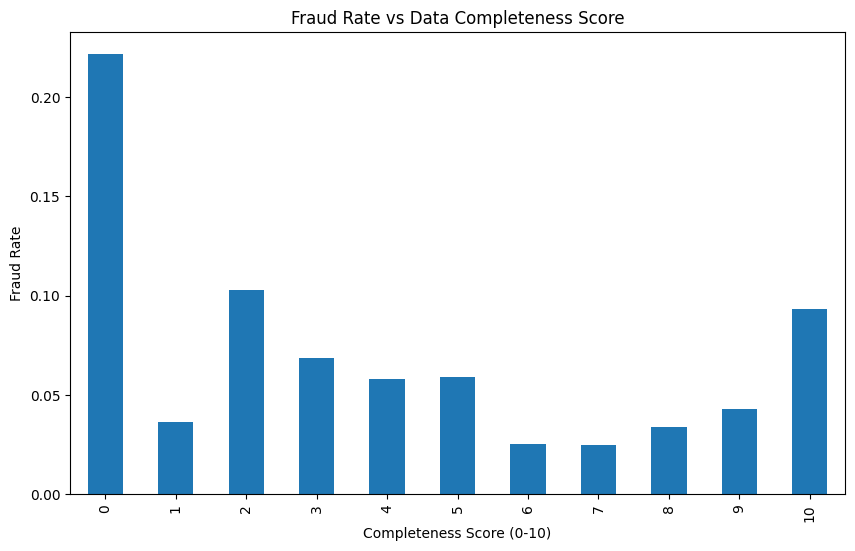

In [18]:
print("Fraud Rate by Completeness Score:")
print(fraud_by_completeness)

# Visualize it
import matplotlib.pyplot as plt
fraud_by_completeness['mean'].plot(kind='bar', figsize=(10,6))
plt.xlabel('Completeness Score (0-10)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate vs Data Completeness Score')
plt.show()


In [19]:
print("\nFraud Rate Analysis by Feature Presence:")
print("-" * 60)
print(f"{'Feature':<25} {'Present':<15} {'Missing':<15} {'Diff':<10}")
print("-" * 60)

for col in ['has_salary', 'has_department', 'has_benefits', 'has_requirements',
            'has_experience', 'has_education', 'has_industry', 'has_function',
            'has_employment_type', 'has_company_profile']:

    fraud_rate_present = df[df[col]==1]['fraudulent'].mean()
    fraud_rate_missing = df[df[col]==0]['fraudulent'].mean()
    diff = fraud_rate_missing - fraud_rate_present

    print(f"{col:<25} {fraud_rate_present*100:>6.2f}%       {fraud_rate_missing*100:>6.2f}%      {diff*100:>+6.2f}%")



Fraud Rate Analysis by Feature Presence:
------------------------------------------------------------
Feature                   Present         Missing         Diff      
------------------------------------------------------------
has_salary                  7.78%         4.28%       -3.49%
has_department              5.29%         4.60%       -0.69%
has_benefits                4.71%         5.05%       +0.34%
has_requirements            4.69%         5.71%       +1.02%
has_experience              3.98%         6.17%       +2.19%
has_education               4.25%         5.56%       +1.32%
has_industry                4.55%         5.61%       +1.05%
has_function                4.63%         5.22%       +0.59%
has_employment_type         4.34%         6.94%       +2.61%
has_company_profile         1.91%        17.74%      +15.83%


In [20]:
from scipy.stats import chi2_contingency

print("\nChi-Square Tests for Missingness vs Fraud:")
print("-" * 60)

for col in ['has_salary', 'has_department', 'has_benefits', 'has_requirements']:
    contingency_table = pd.crosstab(df[col], df['fraudulent'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"{col}: Chi2={chi2:.2f}, p-value={p_value:.4e} {'***' if p_value < 0.001 else ''}")



Chi-Square Tests for Missingness vs Fraud:
------------------------------------------------------------
has_salary: Chi2=62.96, p-value=2.1067e-15 ***
has_department: Chi2=4.09, p-value=4.3126e-02 
has_benefits: Chi2=1.02, p-value=3.1350e-01 
has_requirements: Chi2=4.98, p-value=2.5651e-02 


In [21]:
print("\nPattern-Based Fraud Detection:")
print(f"Bare Bones Pattern: {df[df['bare_bones']==1]['fraudulent'].mean()*100:.2f}% fraud rate")
print(f"No Company Info Pattern: {df[df['no_company_info']==1]['fraudulent'].mean()*100:.2f}% fraud rate")
print(f"Overall fraud rate: {df['fraudulent'].mean()*100:.2f}%")

# Show counts
print(f"\nPostings matching 'bare_bones': {df['bare_bones'].sum()} ({df['bare_bones'].sum()/len(df)*100:.1f}%)")
print(f"Postings matching 'no_company_info': {df['no_company_info'].sum()} ({df['no_company_info'].sum()/len(df)*100:.1f}%)")



Pattern-Based Fraud Detection:
Bare Bones Pattern: 6.21% fraud rate
No Company Info Pattern: 24.45% fraud rate
Overall fraud rate: 4.84%

Postings matching 'bare_bones': 2671 (14.9%)
Postings matching 'no_company_info': 961 (5.4%)


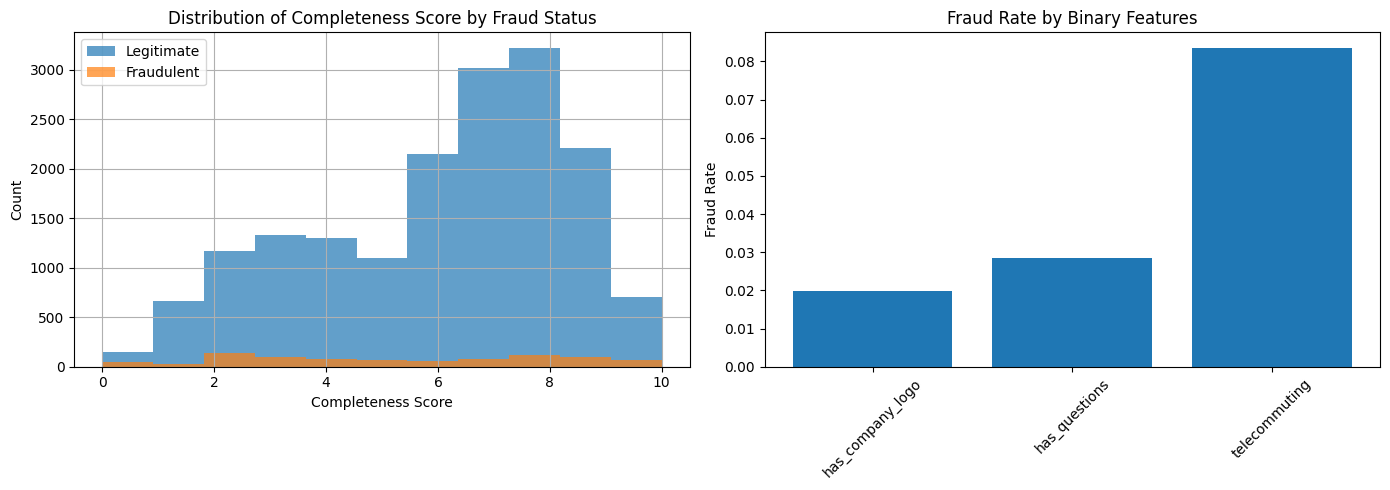

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Completeness score by fraud status
df[df['fraudulent']==0]['completeness_score'].hist(bins=11, alpha=0.7, label='Legitimate', ax=axes[0])
df[df['fraudulent']==1]['completeness_score'].hist(bins=11, alpha=0.7, label='Fraudulent', ax=axes[0])
axes[0].set_xlabel('Completeness Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Completeness Score by Fraud Status')
axes[0].legend()

# Binary features analysis
binary_cols = ['has_company_logo', 'has_questions', 'telecommuting']
fraud_rates = [df[df[col]==1]['fraudulent'].mean() for col in binary_cols]
axes[1].bar(binary_cols, fraud_rates)
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Fraud Rate by Binary Features')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [23]:
# Capture the U-shaped relationship
df['completeness_squared'] = df['completeness_score'] ** 2
df['completeness_cubed'] = df['completeness_score'] ** 3

# Distance from "safe zone" (scores 6-7)
df['distance_from_safe_zone'] = df['completeness_score'].apply(
    lambda x: min(abs(x - 6), abs(x - 7))
)


In [24]:
# Explicit risk zone categorization
def categorize_risk_zone(score):
    if score == 0:
        return 'extreme_risk'  # 22% fraud rate
    elif score in [1]:
        return 'very_low_risk'  # 3.6% fraud rate
    elif score in [2]:
        return 'elevated_risk'  # 10% fraud rate
    elif score in [6, 7]:
        return 'low_risk'  # 2.5% fraud rate
    elif score == 10:
        return 'sophisticated_fraud_risk'  # 9.3% fraud rate
    else:
        return 'moderate_risk'  # ~4-6% fraud rate

df['risk_zone'] = df['completeness_score'].apply(categorize_risk_zone)


In [25]:
# Identify suspiciously perfect postings
df['too_perfect'] = (df['completeness_score'] == 10).astype(int)

# Combined risk indicator
df['extreme_completeness'] = (
    (df['completeness_score'] == 0) |
    (df['completeness_score'] == 10)
).astype(int)


In [26]:
from scipy.stats import chi2_contingency

# Test if score 10 fraud rate differs significantly from baseline
score_10_vs_baseline = pd.DataFrame({
    'fraud': [df[df['completeness_score']==10]['fraudulent'].sum(),
              df[df['completeness_score']!=10]['fraudulent'].sum()],
    'legit': [df[df['completeness_score']==10]['fraudulent'].count() -
              df[df['completeness_score']==10]['fraudulent'].sum(),
              df[df['completeness_score']!=10]['fraudulent'].count() -
              df[df['completeness_score']!=10]['fraudulent'].sum()]
})

chi2, p_value, _, _ = chi2_contingency(score_10_vs_baseline)
print(f"Score 10 vs Others: p-value = {p_value}")


Score 10 vs Others: p-value = 5.81223859787911e-09
